In [1]:
import os
import shutil
import json
import re

import matplotlib.pyplot as plt

from p3_eval_funcitions import *
from eval_functions_p1 import *
from plot_functions_p1 import *

In [2]:
models = get_models('model_output')
model_name = models[1]
model_name

'Llama3_70b_Fine-Tuned_p3_ep5_p1'

In [3]:
label_folder = "../../input/lct_p3"
model_folder = f"model_output/{model_name}/output"
ready_folder = f"model_output/{model_name}/ready"
failure_folder = f"model_output/{model_name}/failure"

categories = ['Condition', 'Observation', 'Drug']

#### Filter failure model files

In [4]:
read_and_process_files(model_name)

In [5]:
def visit(node, category, entities):
    if isinstance(node, dict):
        if category in node:
            entities.extend(node[category])
        for value in node.values():
            visit(value, category, entities)
    elif isinstance(node, list):
        for item in node:
            visit(item, category, entities)

def calculate_metrics(label_data, model_data, metrics):
    for category in categories:
        label_entities = []
        visit(label_data, category, label_entities)
        model_entities = []
        visit(model_data, category, model_entities)

        true_positives = sum(entity in label_entities for entity in model_entities)
        false_positives = sum(entity not in label_entities for entity in model_entities)
        false_negatives = sum(entity not in model_entities for entity in label_entities)

        metrics[category]['true_positives'] += true_positives
        metrics[category]['false_positives'] += false_positives
        metrics[category]['false_negatives'] += false_negatives

        # Count total entities in labels and model outputs
        metrics[category]['total_label_entities'] += len(label_entities)
        metrics[category]['total_model_entities'] += len(model_entities)

def process_files(label_folder, model_folder):
    metrics = {category: {'true_positives': 0, 'false_positives': 0, 'false_negatives': 0,
                          'total_label_entities': 0, 'total_model_entities': 0} for category in categories}
    for filename in os.listdir(model_folder):

        if filename.endswith('.json'):
            model_path = os.path.join(model_folder, filename)
            match = re.search(r'NCT\d+_(?:exc|inc)', filename)
            if match:
                label_filename = f"{match.group(0)}.json"
                label_path = os.path.join(label_folder, label_filename)

                if os.path.exists(label_path):
                    try:
                        with open(label_path, 'r', encoding='utf-8') as label_file, open(model_path, 'r', encoding='utf-8') as model_file:
                            label_data = json.load(label_file)
                            model_data = json.load(model_file)
    
                            calculate_metrics(label_data, model_data, metrics)
                    except json.JSONDecodeError as e:
                        print(f"Error decoding JSON file: {model_path}")
                        print(f"Error message: {str(e)}")

    for category in categories:
        true_positives = metrics[category]['true_positives']
        false_positives = metrics[category]['false_positives']
        false_negatives = metrics[category]['false_negatives']

        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = true_positives / (true_positives + false_positives + false_negatives) if (true_positives + false_positives + false_negatives) > 0 else 0

        metrics[category]['precision'] = precision
        metrics[category]['recall'] = recall
        metrics[category]['f1'] = f1
        metrics[category]['accuracy'] = accuracy

    return metrics

In [6]:
metrics = process_files(label_folder, ready_folder)

In [7]:
print("Metrics:")
for category, scores in metrics.items():
    print(f"{category}:")
    print(f"  Precision: {scores['precision']:.4f}")
    print(f"  Recall: {scores['recall']:.4f}")
    print(f"  F1-score: {scores['f1']:.4f}")
    print(f"  Accuracy: {scores['accuracy']:.4f}")

Metrics:
Condition:
  Precision: 0.5543
  Recall: 0.5726
  F1-score: 0.5633
  Accuracy: 0.3921
Observation:
  Precision: 0.3804
  Recall: 0.3131
  F1-score: 0.3435
  Accuracy: 0.2074
Drug:
  Precision: 0.7640
  Recall: 0.7193
  F1-score: 0.7410
  Accuracy: 0.5885


#### Anzahl der Fehler in der Modelausgabe

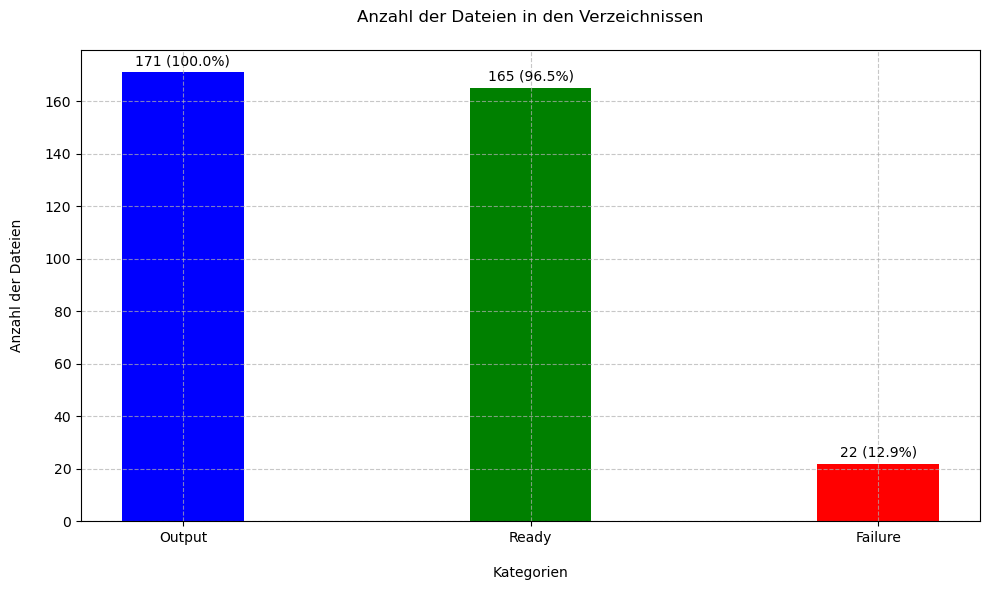

In [8]:
plot_file_counts(model_name)

### Anzahl der ausgegebenen Entitäten

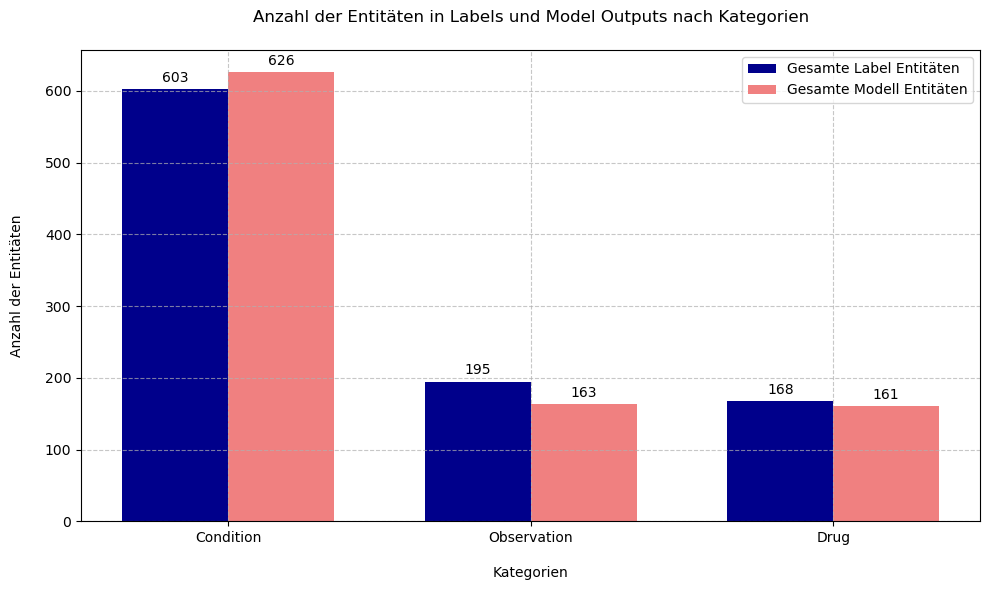

In [9]:
plot_entitys(metrics, model_name)

In [53]:
def plot_metrics(model_name, metrics):
    categories = ['Condition', 'Drug', 'Observation']
    metrics_to_plot = ['precision', 'recall', 'f1']
    metric_labels = {'precision': 'P', 'recall': 'R', 'f1': 'F1'}
    sota_metrics = {
        'SciBERT': {
            'Condition': {'precision': 78.4, 'recall': 83.3, 'f1': 80.8},
            'Drug': {'precision': 73.4, 'recall': 80.9, 'f1': 77.0},
            'Observation': {'precision': 72.1, 'recall': 77.6, 'f1': 74.7},
            'average': {'precision': 74.63, 'recall': 80.60, 'f1': 77.50}
        }
    }
    fig, ax = plt.subplots(figsize=(16, 10))

    x = np.arange(len(categories))
    bar_width = 0.4
    opacity = 0.8
    gap = 0.1

    for i, metric in enumerate(metrics_to_plot):
        model_values = [metrics[category][metric] * 100 for category in categories]
        sota_values = [sota_metrics['SciBERT'][category][metric] for category in categories]

        ax.bar(x - bar_width/2 - gap/2 + i*bar_width/3, model_values, bar_width/3, alpha=opacity, label=f'{model_name.split("-Instruct")[0]} - {metric_labels[metric]}')
        ax.bar(x + bar_width/2 + gap/2 + i*bar_width/3, sota_values, bar_width/3, alpha=opacity, label=f'SciBERT - {metric_labels[metric]}')

        for j, (model_value, sota_value) in enumerate(zip(model_values, sota_values)):
            ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
            ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

            ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value + 2, f'{model_value:.1f}%', ha='center', fontsize=12)
            ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value + 2, f'{sota_value:.1f}%', ha='center', fontsize=12)

    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=14)
    ax.set_xlabel('Category', fontsize=16, fontweight='bold', labelpad=15)
    ax.set_ylabel('Score (%)', fontsize=16, fontweight='bold', labelpad=15)
    ax.set_ylim(0, 105)
    ax.set_yticks(np.arange(0, 101, 10))
    ax.tick_params(axis='y', labelsize=14, width=2)
    ax.yaxis.set_tick_params(labelsize=14)
    ax.set_title(f'Evaluation: {model_name} vs. SciBERT', fontsize=20, pad=20)
    ax.legend(fontsize=12, ncol=2, loc='upper left')
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(f'pics/evaluation_{model_name}.png')
    plt.show()

#### Model Performance

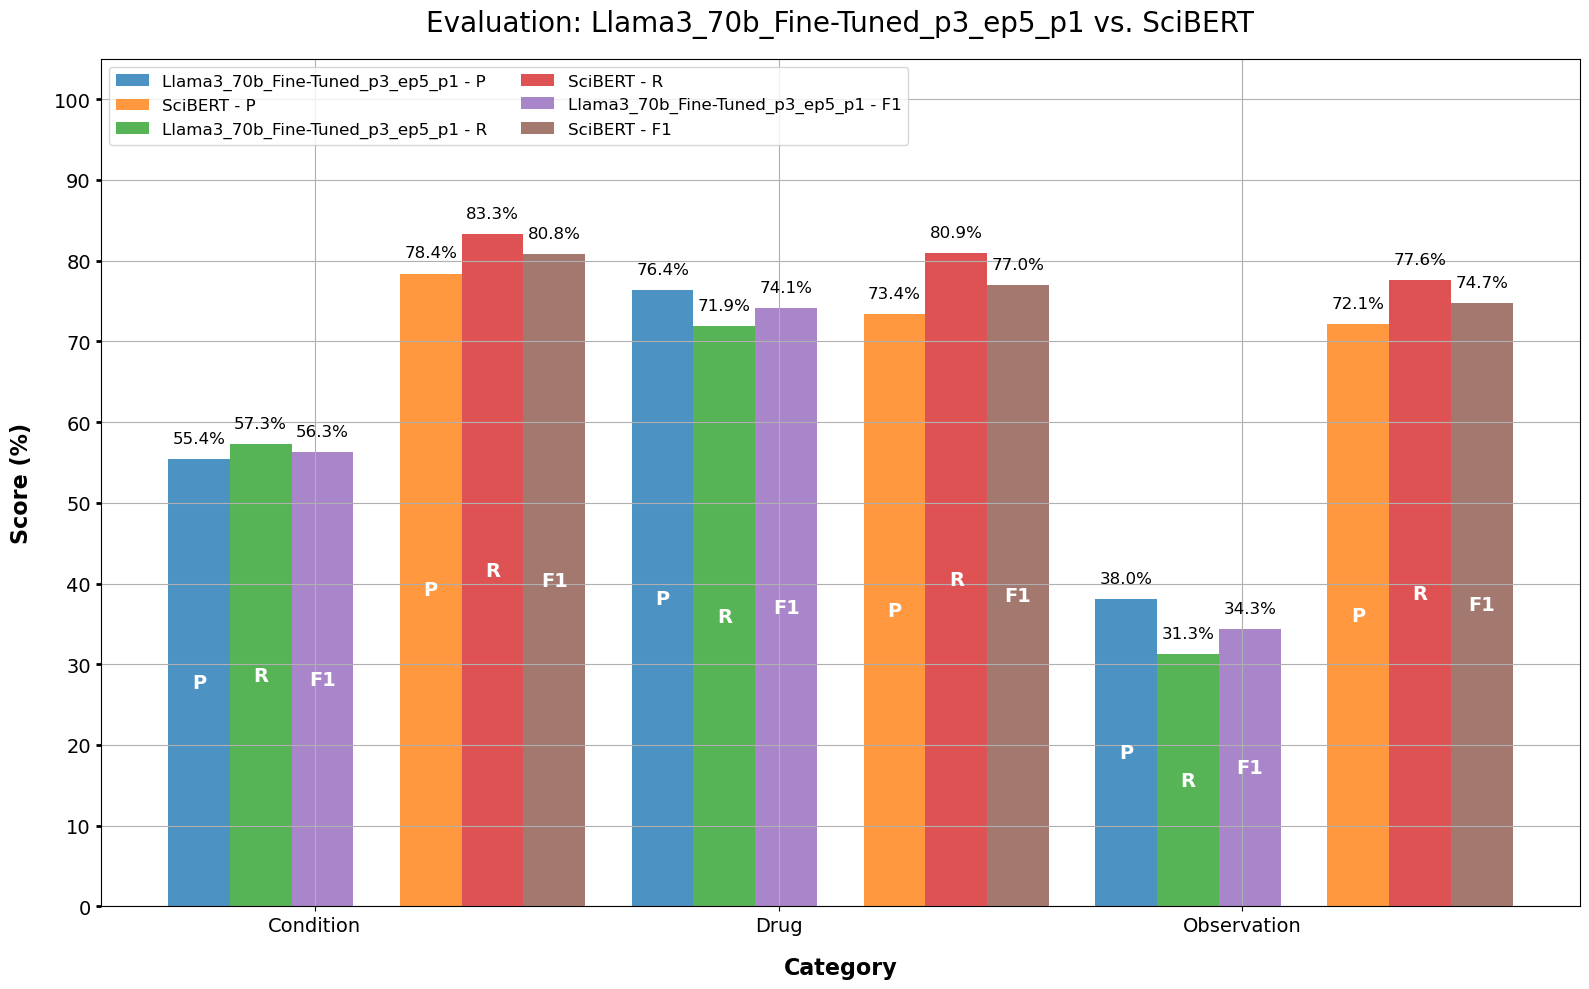

In [54]:
plot_metrics(model_name, metrics)

In [4]:
#versuch_ordner = "eval_p1_temp/" 

label_folder = '../../input/lct_p1'
raw_lct_text_folder = '../../input/lct_txt'
model_output_folder = 'model_output/' #versuch_ordner + 

models = [folder for folder in os.listdir(model_output_folder) if os.path.isdir(os.path.join(model_output_folder, folder))]
models

['Llama-3-70B-Instruct_3_shot']

In [5]:
all_metrics = {}
for model in models:
    model_folder = os.path.join(model_output_folder, model, 'combined_output')
    metrics = evaluate_models(label_folder, model_folder, model, raw_lct_text_folder)
    all_metrics[model] = metrics

NCT03860012
label_words_dict []
model_words_dict ['disease', 'dosing', 'study', 'acid']
[]
label_words_dict ['21']
model_words_dict ['levels', '21']
['21']
label_words_dict []
model_words_dict []
[]
NCT03860064
label_words_dict ['18', 'uterus']
model_words_dict ['women', 'kgm2', 'karyotype', 'years']
[]
label_words_dict ['chemotherapy']
model_words_dict ['carriers', 'aspiration']
[]
label_words_dict []
model_words_dict []
[]
NCT03860090
label_words_dict []
model_words_dict ['electrode', 'lymphadenectomy']
[]
label_words_dict ['pacemaker']
model_words_dict []
[]
label_words_dict []
model_words_dict []
[]
NCT03860103
label_words_dict []
model_words_dict ['study', 'old', 'scheme', 'pregnancy', 'amenorrhea', 'persons', 'scheme']
[]
label_words_dict ['preeclampsia', 'guardianship']
model_words_dict ['Minors', 'guardianship']
['guardianship']
label_words_dict []
model_words_dict []
[]
NCT03860116
label_words_dict []
model_words_dict ['positive', 'recruitment', 'behavior', 'phone', 'daily', '

In [7]:
def plot_avg_metrics(all_metrics):
    sota_metrics = {
        'SciBERT (SOTA)': {
            'average': {'precision': 71.16, 'recall': 81.39, 'f1': 75.89}
        },
        'R-BERT + SciBERT': {
            'average': {'precision': 72.23, 'recall': 78.23, 'f1': 75.0}
        }
    }
    metrics_to_plot = ['precision', 'recall', 'f1']
    model_names = ['SciBERT (SOTA)'] + list(all_metrics.keys())
    model_names = [name.replace('-Instruct', '') for name in model_names]  # Entferne "-Instruct" aus den Modellnamen
    model_names = [name.replace('_', '-') for name in model_names]  # Ersetze "_" durch "-"
    model_names = [name.replace('Gradient', 'Grad') for name in model_names]  # Ersetze "Gradient" durch "Grad"

    avg_precisions = [sota_metrics['SciBERT (SOTA)']['average']['precision']]
    avg_recalls = [sota_metrics['SciBERT (SOTA)']['average']['recall']]
    avg_f1_scores = [sota_metrics['SciBERT (SOTA)']['average']['f1']]

    for model, metrics in all_metrics.items():
        avg_precisions.append(metrics['average']['precision'])
        avg_recalls.append(metrics['average']['recall'])
        avg_f1_scores.append(metrics['average']['f1'])

    x = np.arange(len(model_names) * 4)
    bar_width = 1.5  # Breitere Balken
    opacity = 0.8
    gap = 0.55 # Abstand zwischen den Balken
    model_gap = 1.0  # Abstand zwischen den Modellen

    plt.figure(figsize=(14, 10))  # Größere Figur
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Bessere Farben
    for i in range(len(model_names)):
        plt.bar(x[i * 4], avg_precisions[i], bar_width - gap, alpha=opacity, label='Precision' if i == 0 else '', color=colors[0])
        plt.bar(x[i * 4 + 1], avg_recalls[i], bar_width - gap, alpha=opacity, label='Recall' if i == 0 else '', color=colors[1])
        plt.bar(x[i * 4 + 2], avg_f1_scores[i], bar_width - gap, alpha=opacity, label='F1 Score' if i == 0 else '', color=colors[2])

    plt.xlabel('Models', fontsize=14)
    plt.ylabel('Score (%)', fontsize=14)
    plt.title('Ergebnisse der Auswertung über alle Operatoren', fontsize=18, pad=20)
    plt.xticks(x[1::4], model_names, rotation=45, ha='right', fontsize=14)
    plt.ylim(0, 100)
    plt.yticks(fontsize=14)  # Größere Zahlen an der y-Achse
    plt.legend(fontsize=14)
    plt.grid(True)

    y_offset = 2  # Abstand zwischen Balken und Prozentzahlen
    for i in range(len(model_names)):
        plt.text(x[i * 4], avg_precisions[i] + y_offset, f'{avg_precisions[i]:.1f}%', ha='center', fontsize=12)
        plt.text(x[i * 4 + 1], avg_recalls[i] + y_offset, f'{avg_recalls[i]:.1f}%', ha='center', fontsize=12)
        plt.text(x[i * 4 + 2], avg_f1_scores[i] + y_offset, f'{avg_f1_scores[i]:.1f}%', ha='center', fontsize=12)

    plt.tight_layout()
    plt.show()

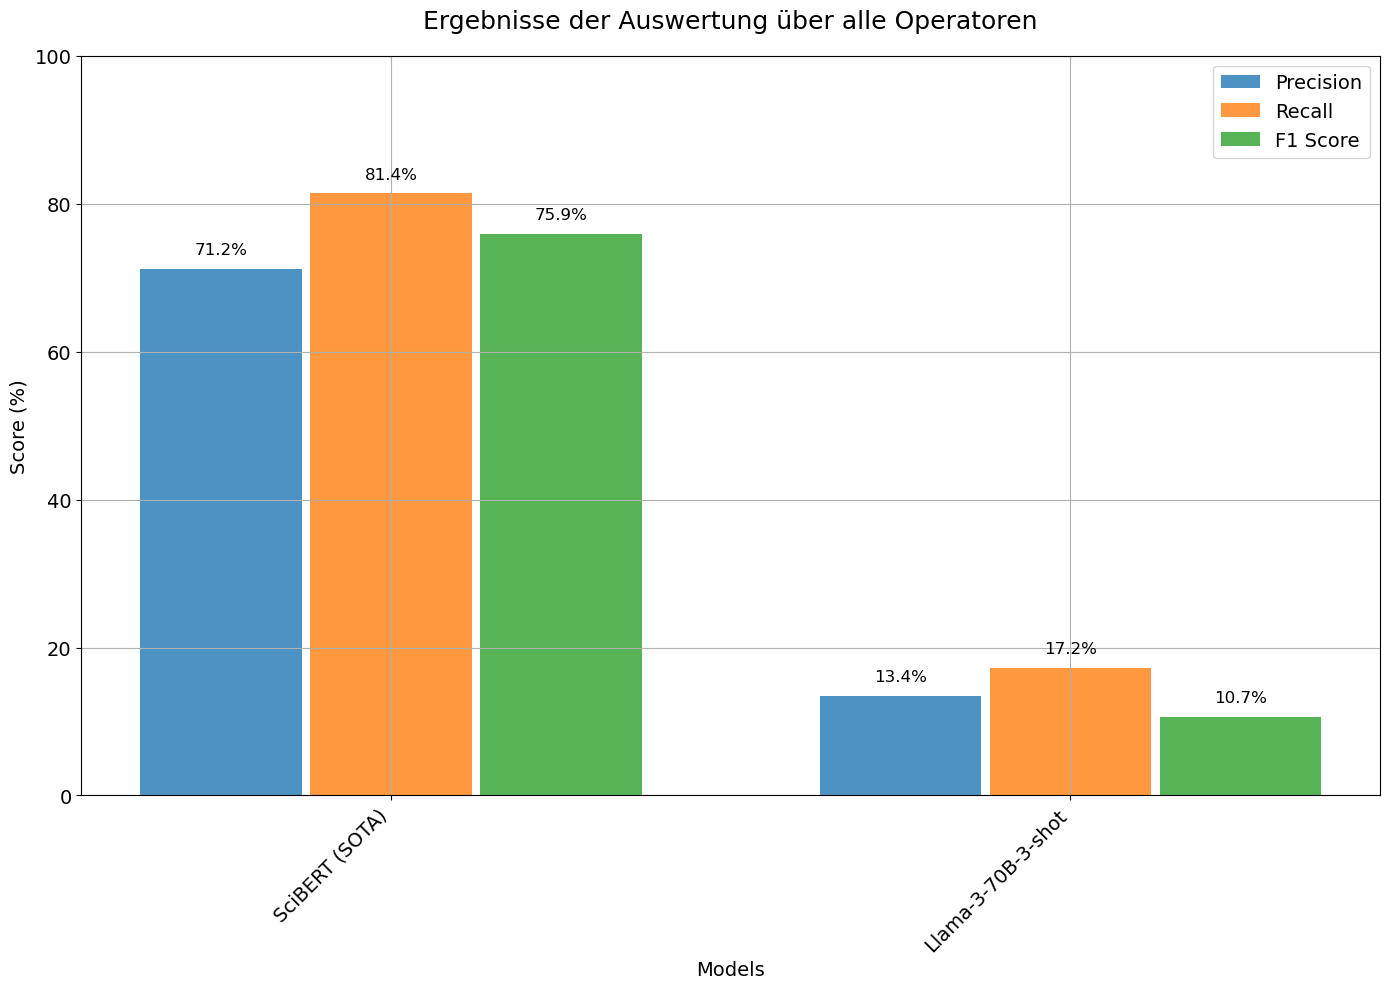

In [8]:
plot_avg_metrics(all_metrics)